In [10]:
import networkx as nx
import scipy.stats
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import seaborn as sns
from tqdm import tqdm
from networkx.algorithms.community import louvain_communities
import scipy.io as spio
import json
from collections import Counter

### q1: model testing/comparison

Calculating features for network 2: 100%|██████████| 100/100 [00:02<00:00, 42.40it/s]


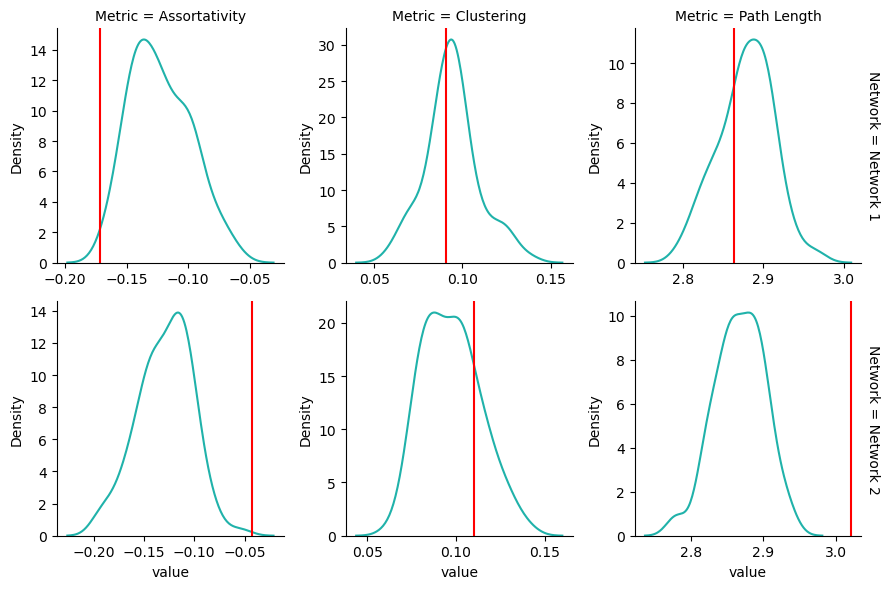

In [ ]:
net1 = nx.read_adjlist(r'./supp/mystery_edges1.txt')
net2 = nx.read_adjlist(r'./supp/mystery_edges2.txt')
networks = [net1, net2]
nulls = {}

for G in networks:
    nulls[G] = []
    size = len(G.nodes())
    # m must be num edges per node if BA model
    best_m = int(round(len(G.edges())/size))
    for _ in range(100):
        g = nx.barabasi_albert_graph(size, best_m)
        nulls[G].append(g)

# adapting plots from notebook

# making dict hashable
nulls2 = frozenset((k, tuple(v)) for k, v in nulls.items())

rows = []
for G in tqdm(nulls[net1], desc="Calculating features for network 1"):
    t = nx.degree_assortativity_coefficient(G)
    c = nx.average_clustering(G)
    d = nx.average_shortest_path_length(G)
    rows.append((t,c,d,"Network 1"))
for G in tqdm(nulls[net2], desc="Calculating features for network 2"):
    t = nx.degree_assortativity_coefficient(G)
    c = nx.average_clustering(G)
    d = nx.average_shortest_path_length(G)
    rows.append((t,c,d,"Network 2"))
df = pd.DataFrame(rows, columns=["Assortativity", "Clustering", "Path Length", "Network"])

df2 = df.melt(id_vars=["Network"], var_name="Metric")

g = sns.FacetGrid(df2, row="Network", col='Metric', sharex=False, sharey=False, despine=True, margin_titles=True)
g.map(sns.kdeplot, "value", color="lightseagreen")
g.axes[0,0].axvline(x=nx.degree_assortativity_coefficient(net1), color='r')
g.axes[0,1].axvline(x=nx.average_clustering(net1), color='r')
g.axes[0,2].axvline(x=nx.average_shortest_path_length(net1), color='r')
g.axes[1,0].axvline(x=nx.degree_assortativity_coefficient(net2), color='r')
g.axes[1,1].axvline(x=nx.average_clustering(net2), color='r')
g.axes[1,2].axvline(x=nx.average_shortest_path_length(net2), color='r')
g.tight_layout()
plt.savefig(r'./imgs/q1.png')
plt.show()

### q2: guimera replication

In [ ]:
ms = list(range(1,6))
sizes = np.arange(50, 351, 50)
results = {}

for m in ms:
    results[m] = {}
    for size in sizes:
        mods = []
        for _ in range(50):
            G = nx.barabasi_albert_graph(size, m)
            mod = nx.community.modularity(G, louvain_communities(G))
            mods.append(mod)
        avgmod = np.mean(mods)
        results[m][size] = avgmod

# plotting

# Define markers for each m value
markers = {1: 'o', 2: 's', 3: 'd', 4: '^', 5: '<'}
colors = ['black'] * 5 # Original plot is monochrome

plt.figure(figsize=(8,6))

# Unpacking nested dict for each m
for m in ms:
    sorted_sizes = sorted(results[m].keys())
    y_values = [results[m][s] for s in sorted_sizes]

    # Plotting discrete points with open markers
    plt.plot(sorted_sizes, y_values, 
             marker=markers.get(m), 
             linestyle='-', # Connects with a line like the figure
             color='black', 
             markerfacecolor='none', # Open markers
             markeredgecolor='black',
             label=f'm = {m}')

# Formatting to match the image aesthetics
plt.xlabel('Size, S', fontsize=12)
plt.ylabel('Modularity', fontsize=12)
plt.xlim(0, 400)
plt.ylim(0.2, 0.9)
plt.legend(frameon=False) # Remove legend box for a cleaner look
plt.tick_params(direction='in', top=True, right=True) # Inward ticks
#plt.savefig(r'./imgs/2/q2.png')
plt.show()

### q3: exploring community detection

In [ ]:
# part a

# cant be read into by nx directly so converting to ndarray first
matrix = spio.mmread(r'./supp/polblogs.mtx')

# trimming useless nodes
G_full = nx.from_scipy_sparse_array(matrix)
G_conn = max(nx.connected_components(G_full), key=len)
G = G_full.subgraph(G_conn)

partition = nx.community.louvain_communities(G)
modularity = nx.community.modularity(G, partition)

print(f"Modularity: {modularity}")
print(f"# Communities: {len(partition)}")

# mapping nodes to communities
comm_map = {}
for i, comm in enumerate(partition):
    for node in comm:
        comm_map[node] = i

# visualizing
comms = range(len(partition)) # range for iteration
# dict comprehension for color map
cmap = plt.get_cmap('tab20')
color_map = {i: cmap(i&20) for i in comms} 
node_colors = [color_map[comm_map[n]] for n in G.nodes()]

nx.draw(G, node_color=node_colors, node_size=25)
#plt.savefig(r'./imgs/communities.png')

In [ ]:
# part b

# re-importing stuff cause different environment

import graph_tool.all as gt
from graph_tool.all import Graph
import scipy.stats
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io as spio
import json

matrix = spio.mmread(r'./supp/polblogs.mtx')

# trimming network graph-tool style
g_full = Graph(matrix)
vfilt = gt.label_largest_component(g_full)
g_conn = gt.GraphView(g_full, vfilt=vfilt)
g = gt.Graph(g_conn, prune=True)

partition = gt.minimize_blockmodel_dl(g)
comms = partition.get_blocks() # extracting PropertyMap

# visualizing
pos = gt.sfdp_layout(g)
gt.graph_draw(g, 
              pos=pos,
              vertex_fill_color=comms,
              inline=True,
              output=r'./imgs/communities_gt.png')

# saving to dict and writing to file for reuse
partition_dict = {int(v): comms[v] for v in g.vertices()}
with open(r'./supp/comm_gt.json', 'w') as file:
    json.dump(partition_dict, file)

In [15]:
# randomization (nx) (writing to separate file so i can use it in both environments)

degseq = [d for n, d in G.degree()]
nullgraph = nx.configuration_model(degseq)
nx.write_edgelist(nullgraph, r'./supp/null.csv', data=False)

In [ ]:
# gt algo (writing to json because i prefer working in nx environment)

import graph_tool.all as gt
from graph_tool.all import Graph
import scipy.stats
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io as spio
import json

nullgraph = gt.load_graph_from_csv(r'./supp/null.csv')
nullpartition = gt.minimize_blockmodel_dl(nullgraph)
blocks = nullpartition.get_blocks()
nullcomms = {int(v): blocks[v] for v in nullgraph.vertices()}

with open(r'./supp/nullcomm_gt.json', 'w') as file:
    json.dump(nullcomms, file)

In [4]:
# nx algo

nullgraph = nx.read_edgelist(r'./supp/null.csv') # making sure it's coming from the same place
nullcomms = nx.community.louvain_communities(nullgraph)
nullcomm_nx = {}
for i, comm in enumerate(nullcomms):
    for node in comm:
        nullcomm_nx[node] = i

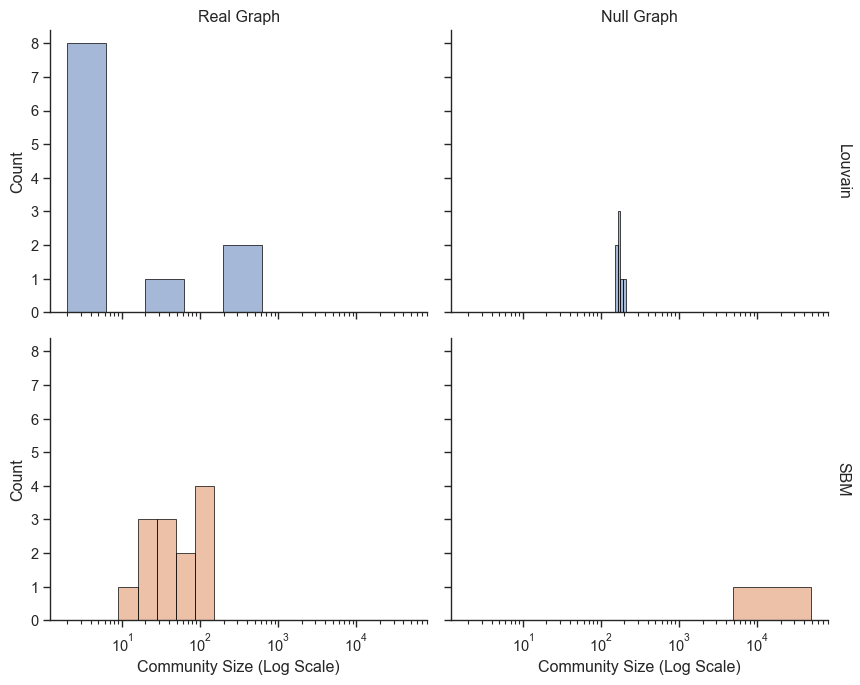

In [ ]:
# part d

# create df from sizes

# counter of how many times each community id appears to get community size
louvain_real = list(Counter(comm_map.values()).values())
louvain_null = list(Counter(nullcomm_nx.values()).values())

with open(r'./supp/comm_gt.json', 'r') as f:
    comm_gt = json.load(f)
sbm_real = list(Counter(comm_gt.values()).values())

with open(r'./supp/nullcomm_gt.json', 'r') as f:
    nullcomm_gt = json.load(f)
sbm_null = list(Counter(nullcomm_gt.values()).values())

# helper to append data
data = []
def add_to_data(sizes, algo, graph):
    for s in sizes:
        data.append({"Size": s, "Algorithm": algo, "Graph": graph})

add_to_data(louvain_real, "Louvain", "Real")
add_to_data(louvain_null, "Louvain", "Null")
add_to_data(sbm_real, "SBM", "Real")
add_to_data(sbm_null, "SBM", "Null")

df = pd.DataFrame(data)

# setting theme before plotting
sns.set_theme(
    context="paper",
    style="ticks",
    font_scale=1.2
)

# using displot since it's most efficient
g = sns.displot(
    data=df,
    x="Size",
    col="Graph",
    row="Algorithm",
    hue="Algorithm",
    kind="hist",
    log_scale=(True, False),
    common_bins=False,
    facet_kws={'margin_titles': True},
    height=3.5,
    aspect=1.25,
    legend=False, # legend is redundant
    edgecolor="black",
    linewidth=0.5
)

# labels and titles
g.set_axis_labels("Community Size (Log Scale)", "Count")
g.set_titles(col_template="{col_name} Graph", row_template="{row_name}")

# aesthetics
sns.despine()
g.tight_layout()

plt.savefig(r"./imgs/community_sizes.png", bbox_inches="tight")
plt.show()

### q4: consensus partition

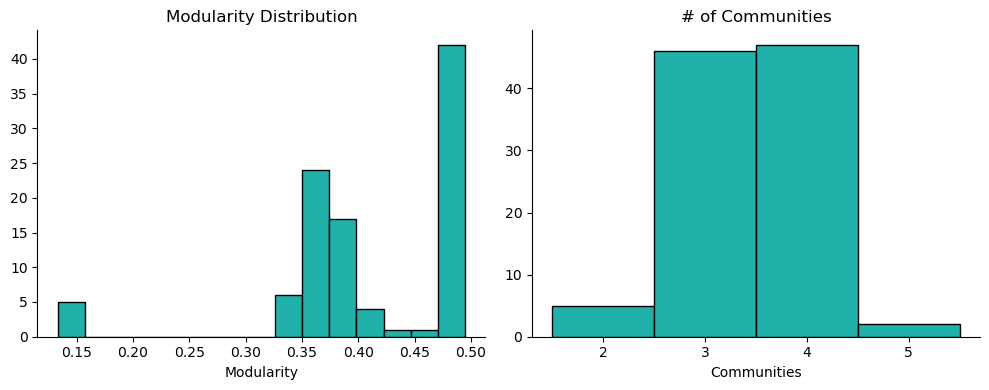

In [ ]:
import graph_tool.all as gt
from graph_tool.all import Graph
import scipy.stats
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io as spio
import json

# === part a: graph generation ===

N = 1000

# defining communities
group_sizes = [100, 200, 300, 400]
b = np.repeat(range(len(group_sizes)), group_sizes)

# storing labels
plant_dict = {i: block_id for i, block_id in enumerate(b)}

ers = np.array([
    [500,  100,  100,  100],
    [ 100, 800,  100,  100],
    [ 100,  100, 1000, 100],
    [ 100,  100,  100, 1200]
])

g = gt.generate_sbm(b, ers, micro_ers=True, directed=False) # micro_ers for microcanonical

# === part b: stochastic partitioning ===

partitions = []
modularities = []
num_communities = []

for r in range(100):
    # new random seed
    np.random.seed(r)
    gt.seed_rng(r)

    # init nodes into random blocks to give mcmc a head start
    b_init = np.random.randint(0, 10, N)

    # initialize and burn-in the markov chain
    state = gt.BlockState(g, b=b_init)
    gt.mcmc_equilibrate(state, wait=10, nbreaks=2, mcmc_args=dict(niter=10))
    
    # storing results
    partitions.append(state.get_blocks().get_array().copy()) # array makes life easier later
    modularities.append(gt.modularity(g, state.get_blocks()))
    num_communities.append(state.get_nonempty_B())

# === part c: plotting ===

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# modularity histogram
axes[0].hist(modularities, bins=15, color='lightseagreen', edgecolor='black')
axes[0].set_title("Modularity Distribution")
axes[0].set_xlabel("Modularity")

# num communities histogram (discrete integer bins)
min_b, max_b = min(num_communities), max(num_communities)
bins = np.arange(min_b, max_b + 2) - 0.5 # center the bars on integers
axes[1].hist(num_communities, bins=bins, color='lightseagreen', edgecolor='black')
axes[1].set_title("# of Communities")
axes[1].set_xlabel("Communities")
axes[1].set_xticks(range(min_b, max_b + 1))

# clean up axes
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(r'./imgs/stochastic_cd_results.png')

Consensus graph found 9 communities


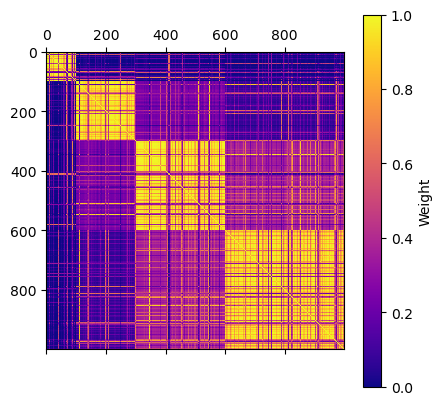

In [16]:
# === part d: consensus matrix ===

def consensus_matrix(partitions=partitions, N=N):
    ''' 
    Builds consensus matrix from a set of partitions generated by a stochastic community
    detection algorithm.

    Args:
    partitions: Dictionary mapping {partition_id: PropertyMap of blocks}
    N: Total number of nodes in the graph

    Returns:
    np.array: Resulting consensus matrix
    '''
    consensus = np.zeros((N, N), dtype=float) # init array
    R = len(partitions)

    for blockmap in partitions:
        
        # numpy trick to compare every element of the array against every other without
        # a nested loop (learned from ai)
        # splits the array into a column vector and a row vector, then stretches them
        # over eachother and creates a boolean matrix depending if the elements are the
        # same or not
        matched_pairs = (blockmap[:, None] == blockmap[None, :])
        
        # add to running total
        consensus += matched_pairs

    # normalization step
    consensus /= R
    
    return consensus

consensus = consensus_matrix()

# visualizing

plt.matshow(consensus, cmap='plasma')
plt.colorbar(label='Weight')
plt.savefig(r'./imgs/consensus_matrix.png')

# === part e: consensus graph ===

# converting to edgelist for graph-tool
rows, cols = np.triu(consensus, 1).nonzero() # avoiding duplicates since undirected
weights = consensus[rows, cols]

# taking only top quartile of weights
mask = weights >= np.quantile(weights, .75)
final_weights = weights[mask]

# build graph
cons_graph = gt.Graph(directed=False)
cons_graph.add_vertex(N) # ensure all N nodes are created first so node ids align

# assign weights and edges at once before building graph
eprop_w = cons_graph.new_edge_property("double") # double precision floating point
edge_data = np.column_stack((rows[mask], cols[mask], final_weights))
cons_graph.add_edge_list(edge_data, eprops=[eprop_w])
cons_graph.ep["weight"] = eprop_w

# final community detection
gt.seed_rng(42)
cons_partition = gt.minimize_blockmodel_dl(cons_graph)

print(f"Consensus graph found {cons_partition.get_nonempty_B()} communities")

Consensus graph found 27 communities


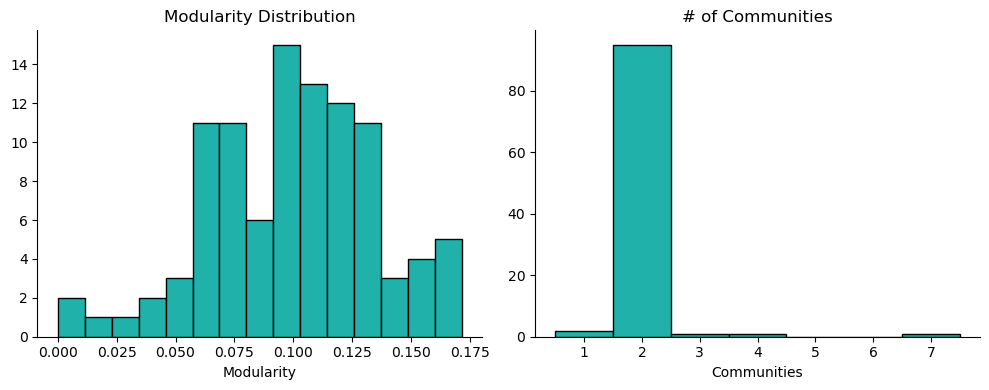

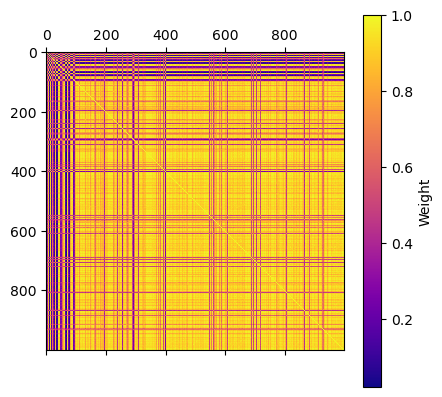

In [17]:
# === part f: weaker community structure ===

# copied/edited from above

# === graph generation ===

N = 1000

# defining communities
group_sizes = [100, 200, 300, 400]
b = np.repeat(range(len(group_sizes)), group_sizes)

# storing labels
plant_dict = {i: block_id for i, block_id in enumerate(b)}

ers_weak = np.array([
    [250,  150,  150,  150],
    [150,  350,  150,  150],
    [150,  150,  450,  150],
    [150,  150,  150,  550]
])

g = gt.generate_sbm(b, ers_weak, micro_ers=True, directed=False) # micro_ers for microcanonical

# === stochastic partitioning ===

partitions = []
modularities = []
num_communities = []

for r in range(100):
    # new random seed
    np.random.choice(range(1000))
    gt.seed_rng(r)

    # init nodes into random blocks to give mcmc a head start
    b_init = np.random.randint(0, 10, N)

    # initialize and burn-in the markov chain
    state = gt.BlockState(g, b=b_init)
    gt.mcmc_equilibrate(state, wait=10, nbreaks=2, mcmc_args=dict(niter=10))
    
    # storing results
    partitions.append(state.get_blocks().get_array().copy()) # array makes life easier later
    modularities.append(gt.modularity(g, state.get_blocks()))
    num_communities.append(state.get_nonempty_B())

# === plotting ===

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# modularity histogram
axes[0].hist(modularities, bins=15, color='lightseagreen', edgecolor='black')
axes[0].set_title("Modularity Distribution")
axes[0].set_xlabel("Modularity")

# num communities histogram (discrete integer bins)
min_b, max_b = min(num_communities), max(num_communities)
bins = np.arange(min_b, max_b + 2) - 0.5 # center the bars on integers
axes[1].hist(num_communities, bins=bins, color='lightseagreen', edgecolor='black')
axes[1].set_title("# of Communities")
axes[1].set_xlabel("Communities")
axes[1].set_xticks(range(min_b, max_b + 1))

# clean up axes
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(r'./imgs/stochastic_cd_results_weak.png')

# === consensus matrix ===

def consensus_matrix(partitions=partitions, N=N):
    ''' 
    Builds consensus matrix from a set of partitions generated by a stochastic community
    detection algorithm.

    Args:
    partitions: Dictionary mapping {partition_id: PropertyMap of blocks}
    N: Total number of nodes in the graph

    Returns:
    np.array: Resulting consensus matrix
    '''
    consensus = np.zeros((N, N), dtype=float) # init array
    R = len(partitions)

    for blockmap in partitions:
        
        # numpy trick to compare every element of the array against every other without
        # a nested loop (learned from ai)
        # splits the array into a column vector and a row vector, then stretches them
        # over eachother and creates a boolean matrix depending if the elements are the
        # same or not
        matched_pairs = (blockmap[:, None] == blockmap[None, :])
        
        # add to running total
        consensus += matched_pairs

    # normalization step
    consensus /= R
    
    return consensus

consensus = consensus_matrix()

# visualizing

plt.matshow(consensus, cmap='plasma')
plt.colorbar(label='Weight')
plt.savefig(r'./imgs/consensus_matrix_weak.png')

# === consensus graph ===

# converting to edgelist for graph-tool
rows, cols = np.triu(consensus, 1).nonzero() # avoiding duplicates since undirected
weights = consensus[rows, cols]

# taking only top quartile of weights
mask = weights >= np.quantile(weights, .75)
final_weights = weights[mask]

# build graph
cons_graph = gt.Graph(directed=False)
cons_graph.add_vertex(N) # ensure all N nodes are created first so node ids align

# assign weights and edges at once before building graph
eprop_w = cons_graph.new_edge_property("double") # double precision floating point
edge_data = np.column_stack((rows[mask], cols[mask], final_weights))
cons_graph.add_edge_list(edge_data, eprops=[eprop_w])
cons_graph.ep["weight"] = eprop_w

# final community detection
gt.seed_rng(42)
cons_partition = gt.minimize_blockmodel_dl(cons_graph)

print(f"Consensus graph found {cons_partition.get_nonempty_B()} communities")